In [1]:

import pandas as pd          # data manipulation
import matplotlib.pyplot as plt  # plotting
import seaborn as sns        # better looking plots
from wordcloud import WordCloud  # word visualization
import mysql.connector       # database connection
from dotenv import load_dotenv  # read .env file
import os                    # access environment variables

load_dotenv()


True

In [2]:
conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME"),
    use_pure=True
)

df = pd.read_sql("SELECT * FROM news_cache", conn)
conn.close()

print(f"Total articles: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")

df.head()

Total articles: 55

Columns: ['id', 'asset', 'headline', 'summary', 'source', 'published_at', 'fetched_at', 'expires_at']


C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\795595203.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM news_cache", conn)


,id,asset,headline,summary,source,published_at,fetched_at,expires_at
0,234,BTC,"Bitcoin, Ethereum, XRP, Dogecoin Spike As Iran...","Leading cryptocurrencies rallied on Thursday, ...",Benzinga,2026-03-13 03:28:22,2026-03-14 01:16:00,2026-03-15 01:16:00
1,235,BTC,Barry Silbert Sees 'Financial Privacy' Becomin...,"Barry Silbert, CEO of cryptocurrency conglomer...",Benzinga,2026-03-12 06:42:45,2026-03-14 01:16:00,2026-03-15 01:16:00
2,236,BTC,Bill Gates Behind Changpeng Zhao In Terms Of W...,Binance (CRYPTO: BNB) co-founder Changpeng “CZ...,Benzinga,2026-03-12 04:12:46,2026-03-14 01:16:00,2026-03-15 01:16:00
3,237,BTC,"Bitcoin, Ethereum, XRP Flat, Dogecoin Slides A...","Leading cryptocurrencies traded flat, while st...",Benzinga,2026-03-12 02:55:39,2026-03-14 01:16:00,2026-03-15 01:16:00
4,238,BTC,Whale's Digital Asset View: Why Bitcoin Is Sol...,"In Perpetual Futures market, Bitcoin exhibited...",SeekingAlpha,2026-03-11 12:50:00,2026-03-14 01:16:01,2026-03-15 01:16:01


BASIC INFO
Total Rows: 55
Total Columns: 8

DATA TYPES
id                       int64
asset                      str
headline                   str
summary                    str
source                     str
published_at    datetime64[us]
fetched_at      datetime64[us]
expires_at      datetime64[us]
dtype: object

NULL VALUES (BEFORE CLEANING)
id              0
asset           0
headline        0
summary         0
source          0
published_at    0
fetched_at      0
expires_at      0
dtype: int64


C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\2767307541.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_counts.index, y=null_counts.values, palette="Reds")


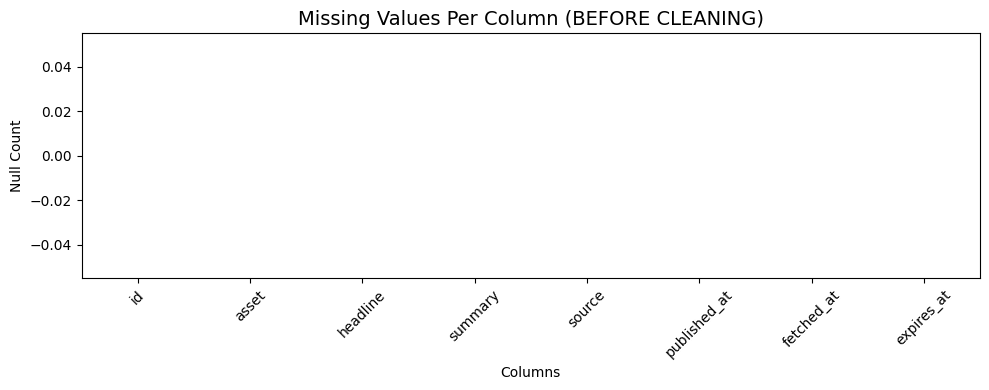


SAMPLE DATA


,headline,summary,source
0,"Bitcoin, Ethereum, XRP, Dogecoin Spike As Iran...","Leading cryptocurrencies rallied on Thursday, ...",Benzinga
1,Barry Silbert Sees 'Financial Privacy' Becomin...,"Barry Silbert, CEO of cryptocurrency conglomer...",Benzinga
2,Bill Gates Behind Changpeng Zhao In Terms Of W...,Binance (CRYPTO: BNB) co-founder Changpeng “CZ...,Benzinga
3,"Bitcoin, Ethereum, XRP Flat, Dogecoin Slides A...","Leading cryptocurrencies traded flat, while st...",Benzinga
4,Whale's Digital Asset View: Why Bitcoin Is Sol...,"In Perpetual Futures market, Bitcoin exhibited...",SeekingAlpha
5,"Bitcoin, Ethereum, XRP, Dogecoin Rebound Amid ...","Leading cryptocurrencies recovered on Tuesday,...",Benzinga
6,"Bitcoin, Ethereum, XRP, Dogecoin Rally As Trum...",Leading cryptocurrencies lifted alongside stoc...,Benzinga
7,"Bitcoin, Ethereum, XRP, Dogecoin Spike 3% As O...","Bitcoin tapped $69,000 on Monday, following a ...",Benzinga
8,Why Wall Street Is Finally Buying Into Crypto,"We talk through institutional adoption, recent...",SeekingAlpha
9,Bitcoin Options Traders Eye Rebound As Volatil...,,SeekingAlpha


In [ ]:


print("=" * 50)
print("BASIC INFO")
print("=" * 50)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("NULL VALUES (BEFORE CLEANING)")
print("=" * 50)
null_counts = df.isnull().sum()
print(null_counts)

# Visualize null values
plt.figure(figsize=(10, 4))
sns.barplot(x=null_counts.index, y=null_counts.values, palette="Reds")
plt.title("Missing Values Per Column (BEFORE CLEANING)", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Null Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("SAMPLE DATA")
print("=" * 50)
df[["headline", "summary", "source"]].head(10)


DUPLICATE CHECK
Total articles:     55
Duplicate headlines:4
Unique headlines:   51


C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\160529684.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


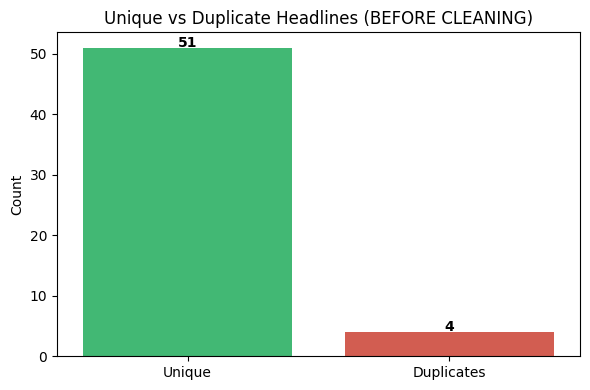


EMPTY TEXT CHECK
Empty headlines: 0
Empty summaries: 4

Sample Headlines:
1. Bitcoin, Ethereum, XRP, Dogecoin Spike As Iran's New Leader Signals Continued Hormuz Strait Closure: Analyst Rules Out BTC's Bullish Reversal Scenario
2. Barry Silbert Sees 'Financial Privacy' Becoming More Important As Leading Bitcoin Mining Pool Operator Dives Into Zcash
3. Bill Gates Behind Changpeng Zhao In Terms Of Wealth? Here's Why The Crypto Billionaire Calls The Estimate A 'Bit Illogical'
4. Bitcoin, Ethereum, XRP Flat, Dogecoin Slides Amid Trump Moves To Combat Iran War Oil Spike: Analyst Says BTC Downside Won't Be 'Heavier'
5. Whale's Digital Asset View: Why Bitcoin Is Sold First In Risk Events


In [ ]:


print("=" * 50)
print("DUPLICATE CHECK")
print("=" * 50)
total = len(df)
duplicates = df.duplicated(subset=["headline"]).sum()
unique = total - duplicates

print(f"Total articles:     {total}")
print(f"Duplicate headlines:{duplicates}")
print(f"Unique headlines:   {unique}")

# Visualize duplicates vs unique
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Unique", "Duplicates"],
    y=[unique, duplicates],
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Unique vs Duplicate Headlines (BEFORE CLEANING)")
plt.ylabel("Count")
for i, v in enumerate([unique, duplicates]):
    plt.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("EMPTY TEXT CHECK")
print("=" * 50)
empty_headlines = df["headline"].str.strip().eq("").sum()
empty_summaries = df["summary"].str.strip().eq("").sum()
print(f"Empty headlines: {empty_headlines}")
print(f"Empty summaries: {empty_summaries}")

# Show sample of headlines
print("\nSample Headlines:")
for i, h in enumerate(df["headline"].head(5)):
    print(f"{i+1}. {h}")
    


FILTERING FOR: OIL
Total articles before filter: 55
After keyword filter: 15
Removed: 40 irrelevant articles


C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\2250930624.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


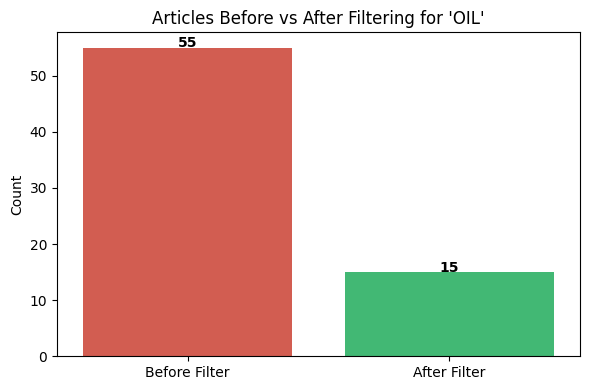


Relevant Headlines for OIL:
1. Bitcoin, Ethereum, XRP Flat, Dogecoin Slides Amid Trump Moves To Combat Iran War Oil Spike: Analyst Says BTC Downside Won't Be 'Heavier'
2. Bitcoin, Ethereum, XRP, Dogecoin Rebound Amid Iran War-Induced Oil Volatility: Analyst Targets BTC Upside Once This Barrier Is Cleared
3. Bitcoin, Ethereum, XRP, Dogecoin Rally As Trump Says Iran War 'Pretty Much' Complete: Analyst Predicts BTC Moves If Oil Keeps Falling
4. Bitcoin, Ethereum, XRP, Dogecoin Spike 3% As Oil Reverses Gains
5. 4 Reasons Why Bitcoin Is Up 4% To $72,000 Today
6. Fed to Delay Rate Cuts as War Clouds the Outlook
7. Trump threatens to strike Iran's Kharg Island oil network if shipping lanes remain blocked
8. Stocks slip, dollar strong as Iran conflict pushes oil prices higher
9. Planned release of strategic reserve would put U.S. supplies at lowest levels in 44 years
10. Planned release of strategic reserve would put U.S. supplies at lowest levels in 44 years
11. Planned release of strategic 

In [ ]:

import re

asset_keyword = input("Enter asset name to analyze: ").strip().lower()

print("\n" + "=" * 50)
print(f"FILTERING FOR: {asset_keyword.upper()}")
print("=" * 50)
print(f"Total articles before filter: {len(df)}")

# Filter - keep only rows where headline OR summary contains keyword
mask = (
    df["headline"].str.lower().str.contains(asset_keyword, na=False) |
    df["summary"].str.lower().str.contains(asset_keyword, na=False)
)
df_filtered = df[mask].copy()

print(f"After keyword filter: {len(df_filtered)}")
print(f"Removed: {len(df) - len(df_filtered)} irrelevant articles")

# Visualize before vs after filtering
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Before Filter", "After Filter"],
    y=[len(df), len(df_filtered)],
    palette=["#e74c3c","#2ecc71"]
)
plt.title(f"Articles Before vs After Filtering for '{asset_keyword.upper()}'")
plt.ylabel("Count")
for i, v in enumerate([len(df), len(df_filtered)]):
    plt.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nRelevant Headlines for {asset_keyword.upper()}:")
for i, h in enumerate(df_filtered["headline"].tolist()):
    print(f"{i+1}. {h}")
    

BEFORE REMOVING DUPLICATES
Total articles: 15
Duplicate headlines: 4

After removing duplicates: 11


C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\2164447747.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


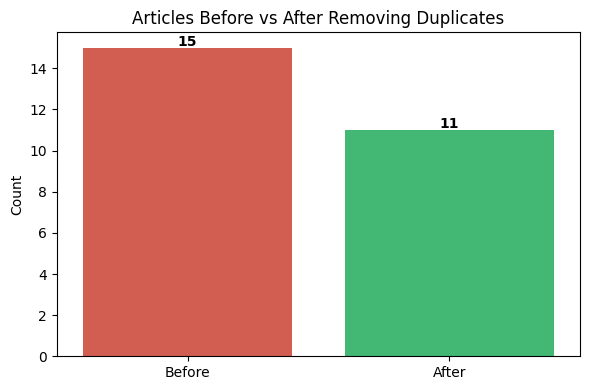


Clean Headlines:
1. Bitcoin, Ethereum, XRP Flat, Dogecoin Slides Amid Trump Moves To Combat Iran War Oil Spike: Analyst Says BTC Downside Won't Be 'Heavier'
2. Bitcoin, Ethereum, XRP, Dogecoin Rebound Amid Iran War-Induced Oil Volatility: Analyst Targets BTC Upside Once This Barrier Is Cleared
3. Bitcoin, Ethereum, XRP, Dogecoin Rally As Trump Says Iran War 'Pretty Much' Complete: Analyst Predicts BTC Moves If Oil Keeps Falling
4. Bitcoin, Ethereum, XRP, Dogecoin Spike 3% As Oil Reverses Gains
5. 4 Reasons Why Bitcoin Is Up 4% To $72,000 Today
6. Fed to Delay Rate Cuts as War Clouds the Outlook
7. Trump threatens to strike Iran's Kharg Island oil network if shipping lanes remain blocked
8. Stocks slip, dollar strong as Iran conflict pushes oil prices higher
9. Planned release of strategic reserve would put U.S. supplies at lowest levels in 44 years
10. Stocks slide and oil climbs on Mid East tensions - Newsquawk US Market Wrap
11. Oil only accounts for half the cost of a gallon of gas

In [16]:
print("=" * 50)
print("BEFORE REMOVING DUPLICATES")
print("=" * 50)
print(f"Total articles: {len(df_filtered)}")

# Check duplicates
duplicates = df_filtered.duplicated(subset=["headline"]).sum()
print(f"Duplicate headlines: {duplicates}")

# Remove duplicates
df_clean = df_filtered.drop_duplicates(subset=["headline"]).copy()
print(f"\nAfter removing duplicates: {len(df_clean)}")

# Visualize
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Before", "After"],
    y=[len(df_filtered), len(df_clean)],
    palette=["#e74c3c", "#2ecc71"]
)
plt.title("Articles Before vs After Removing Duplicates")
plt.ylabel("Count")
for i, v in enumerate([len(df_filtered), len(df_clean)]):
    plt.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nClean Headlines:")
for i, h in enumerate(df_clean["headline"].tolist()):
    print(f"{i+1}. {h}")

In [17]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Original
    original = text
    
    # Step 1 - Lowercase
    text = text.lower()
    
    # Step 2 - Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Step 3 - Remove special characters & punctuation
    text = re.sub(r"[^a-z\s]", "", text)
    
    # Step 4 - Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Apply to both headline and summary
df_clean["clean_headline"] = df_clean["headline"].apply(clean_text)
df_clean["clean_summary"] = df_clean["summary"].apply(clean_text)

# Combine headline + summary for richer analysis
df_clean["full_text"] = df_clean["clean_headline"] + " " + df_clean["clean_summary"]

# Show before vs after
print("=" * 50)
print("BEFORE vs AFTER CLEANING")
print("=" * 50)
for i in range(len(df_clean)):
    print(f"\nArticle {i+1}:")
    print(f"BEFORE: {df_clean['headline'].iloc[i]}")
    print(f"AFTER:  {df_clean['clean_headline'].iloc[i]}")
    print("-" * 40)

BEFORE vs AFTER CLEANING

Article 1:
BEFORE: Bitcoin, Ethereum, XRP Flat, Dogecoin Slides Amid Trump Moves To Combat Iran War Oil Spike: Analyst Says BTC Downside Won't Be 'Heavier'
AFTER:  bitcoin ethereum xrp flat dogecoin slides amid trump moves to combat iran war oil spike analyst says btc downside wont be heavier
----------------------------------------

Article 2:
BEFORE: Bitcoin, Ethereum, XRP, Dogecoin Rebound Amid Iran War-Induced Oil Volatility: Analyst Targets BTC Upside Once This Barrier Is Cleared
AFTER:  bitcoin ethereum xrp dogecoin rebound amid iran warinduced oil volatility analyst targets btc upside once this barrier is cleared
----------------------------------------

Article 3:
BEFORE: Bitcoin, Ethereum, XRP, Dogecoin Rally As Trump Says Iran War 'Pretty Much' Complete: Analyst Predicts BTC Moves If Oil Keeps Falling
AFTER:  bitcoin ethereum xrp dogecoin rally as trump says iran war pretty much complete analyst predicts btc moves if oil keeps falling
---------------

[nltk_data] Downloading package punkt to C:\Users\win
[nltk_data]     11\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\win
[nltk_data]     11\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\1802850755.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


BEFORE vs AFTER TOKENIZATION

Article 1:
BEFORE: bitcoin ethereum xrp flat dogecoin slides amid trump moves to combat iran war oil spike analyst says btc downside wont be heavier leading cryptocurrencies traded flat while stocks fell further on wednesday as president donald trump authorized tapping the strategic reserve to lower oil prices
AFTER:  ['bitcoin', 'ethereum', 'xrp', 'flat', 'dogecoin', 'slides', 'amid', 'trump', 'moves', 'to', 'combat', 'iran', 'war', 'oil', 'spike', 'analyst', 'says', 'btc', 'downside', 'wont', 'be', 'heavier', 'leading', 'cryptocurrencies', 'traded', 'flat', 'while', 'stocks', 'fell', 'further', 'on', 'wednesday', 'as', 'president', 'donald', 'trump', 'authorized', 'tapping', 'the', 'strategic', 'reserve', 'to', 'lower', 'oil', 'prices']
----------------------------------------

Article 2:
BEFORE: bitcoin ethereum xrp dogecoin rebound amid iran warinduced oil volatility analyst targets btc upside once this barrier is cleared leading cryptocurrencies recov

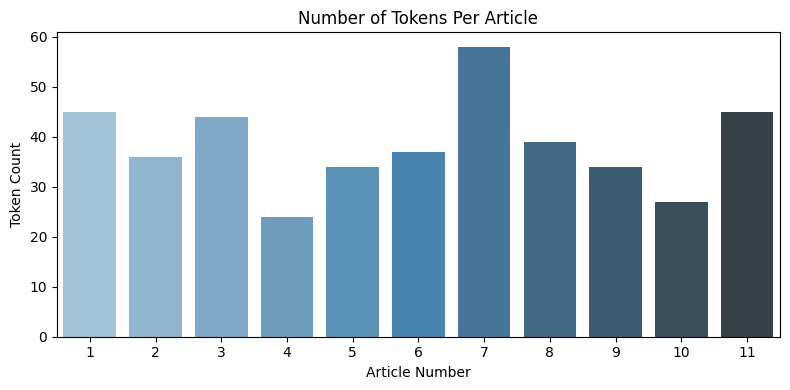


Average tokens per article: 38.5
Max tokens: 58
Min tokens: 24


In [ ]:


import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize

# Tokenize each article
df_clean["tokens"] = df_clean["full_text"].apply(word_tokenize)

# Show before vs after
print("=" * 50)
print("BEFORE vs AFTER TOKENIZATION")
print("=" * 50)
for i in range(len(df_clean)):
    print(f"\nArticle {i+1}:")
    print(f"BEFORE: {df_clean['full_text'].iloc[i]}")
    print(f"AFTER:  {df_clean['tokens'].iloc[i]}")
    print("-" * 40)

# Visualize token count per article
df_clean["token_count"] = df_clean["tokens"].apply(len)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=list(range(1, len(df_clean)+1)),
    y=df_clean["token_count"],
    palette="Blues_d"
)
plt.title("Number of Tokens Per Article")
plt.xlabel("Article Number")
plt.ylabel("Token Count")
plt.tight_layout()
plt.show()

print(f"\nAverage tokens per article: {df_clean['token_count'].mean():.1f}")
print(f"Max tokens: {df_clean['token_count'].max()}")
print(f"Min tokens: {df_clean['token_count'].min()}")

[nltk_data] Downloading package stopwords to C:\Users\win
[nltk_data]     11\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample stopwords:
['or', 'there', 'didn', "he'll", 'on', 'shan', "they've", "she'll", 'here', 't', 'through', 'off', 'our', 'such', 'that', 'these', "they'd", 'as', 'mightn', 'needn']

BEFORE vs AFTER STOPWORD REMOVAL

Article 1:
BEFORE: ['bitcoin', 'ethereum', 'xrp', 'flat', 'dogecoin', 'slides', 'amid', 'trump', 'moves', 'to', 'combat', 'iran', 'war', 'oil', 'spike', 'analyst', 'says', 'btc', 'downside', 'wont', 'be', 'heavier', 'leading', 'cryptocurrencies', 'traded', 'flat', 'while', 'stocks', 'fell', 'further', 'on', 'wednesday', 'as', 'president', 'donald', 'trump', 'authorized', 'tapping', 'the', 'strategic', 'reserve', 'to', 'lower', 'oil', 'prices']
AFTER:  ['bitcoin', 'ethereum', 'xrp', 'flat', 'dogecoin', 'slides', 'amid', 'trump', 'moves', 'combat', 'iran', 'war', 'oil', 'spike', 'analyst', 'says', 'btc', 'downside', 'wont', 'heavier', 'leading', 'cryptocurrencies', 'traded', 'flat', 'stocks', 'fell', 'wednesday', 'president', 'donald', 'trump', 'authorized', 'tapping', 'st

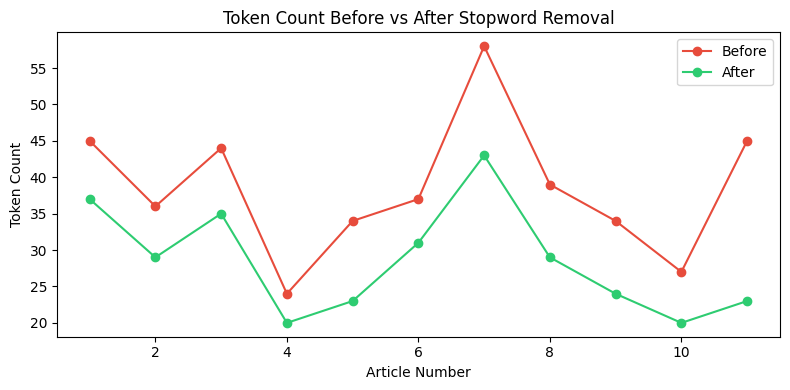

C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\2210455522.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette="viridis")


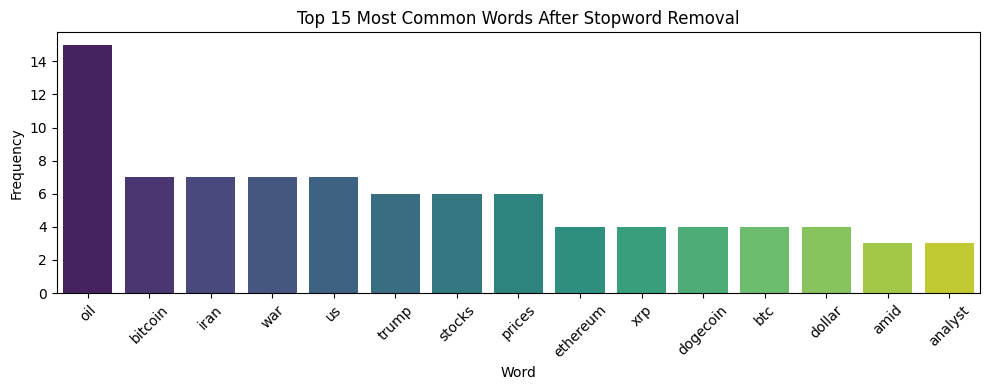

In [ ]:

nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

# Show what stopwords look like
print("Sample stopwords:")
print(list(stop_words)[:20])

# Remove stopwords from tokens
df_clean["tokens_clean"] = df_clean["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

# Show before vs after
print("\n" + "=" * 50)
print("BEFORE vs AFTER STOPWORD REMOVAL")
print("=" * 50)
for i in range(len(df_clean)):
    print(f"\nArticle {i+1}:")
    print(f"BEFORE: {df_clean['tokens'].iloc[i]}")
    print(f"AFTER:  {df_clean['tokens_clean'].iloc[i]}")
    print("-" * 40)

# Visualize token count before vs after
plt.figure(figsize=(8, 4))
x = list(range(1, len(df_clean)+1))
plt.plot(x, df_clean["token_count"], 
         marker="o", label="Before", color="#e74c3c")
plt.plot(x, df_clean["tokens_clean"].apply(len), 
         marker="o", label="After", color="#2ecc71")
plt.title("Token Count Before vs After Stopword Removal")
plt.xlabel("Article Number")
plt.ylabel("Token Count")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize most common words after cleaning
from collections import Counter
all_words = [word for tokens in df_clean["tokens_clean"] for word in tokens]
word_freq = Counter(all_words).most_common(15)

words, counts = zip(*word_freq)
plt.figure(figsize=(10, 4))
sns.barplot(x=list(words), y=list(counts), palette="viridis")
plt.title("Top 15 Most Common Words After Stopword Removal")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package wordnet to C:\Users\win
[nltk_data]     11\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


BEFORE vs AFTER LEMMATIZATION

Article 1:
BEFORE: ['bitcoin', 'ethereum', 'xrp', 'flat', 'dogecoin', 'slides', 'amid', 'trump', 'moves', 'combat', 'iran', 'war', 'oil', 'spike', 'analyst', 'says', 'btc', 'downside', 'wont', 'heavier', 'leading', 'cryptocurrencies', 'traded', 'flat', 'stocks', 'fell', 'wednesday', 'president', 'donald', 'trump', 'authorized', 'tapping', 'strategic', 'reserve', 'lower', 'oil', 'prices']
AFTER:  ['bitcoin', 'ethereum', 'xrp', 'flat', 'dogecoin', 'slide', 'amid', 'trump', 'move', 'combat', 'iran', 'war', 'oil', 'spike', 'analyst', 'say', 'btc', 'downside', 'wont', 'heavier', 'leading', 'cryptocurrencies', 'traded', 'flat', 'stock', 'fell', 'wednesday', 'president', 'donald', 'trump', 'authorized', 'tapping', 'strategic', 'reserve', 'lower', 'oil', 'price']
----------------------------------------

Article 2:
BEFORE: ['bitcoin', 'ethereum', 'xrp', 'dogecoin', 'rebound', 'amid', 'iran', 'warinduced', 'oil', 'volatility', 'analyst', 'targets', 'btc', 'upside'

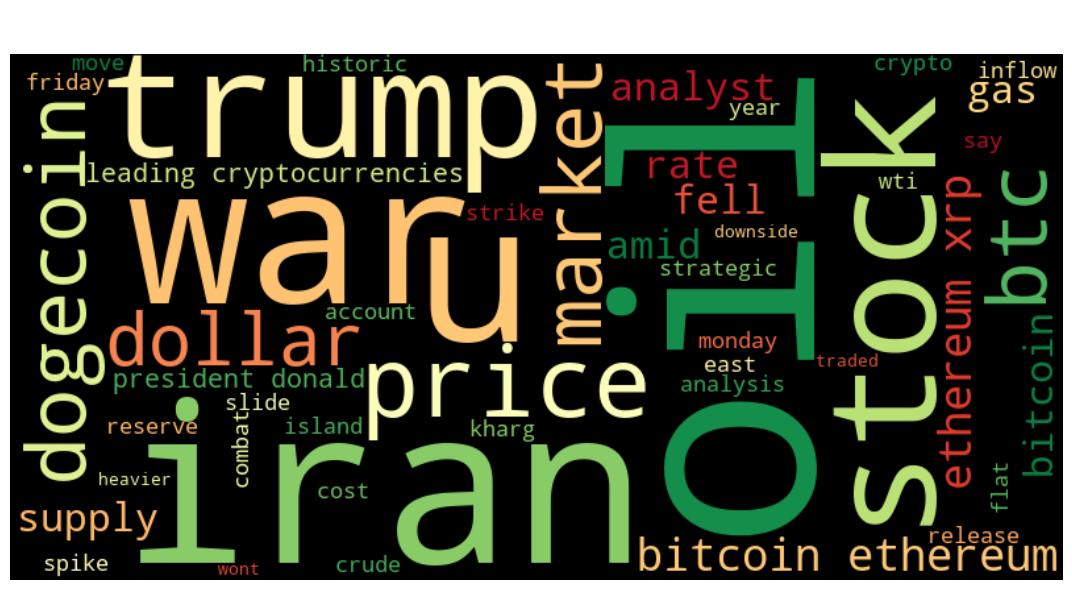


Sample lemmatized words:
{'surging': 'surging', 'climbed': 'climbed', 'fears': 'fear', 'falling': 'falling', 'crashed': 'crashed'}


In [ ]:


nltk.download("wordnet")
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df_clean["tokens_lemma"] = df_clean["tokens_clean"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Show before vs after
print("=" * 50)
print("BEFORE vs AFTER LEMMATIZATION")
print("=" * 50)
for i in range(len(df_clean)):
    print(f"\nArticle {i+1}:")
    print(f"BEFORE: {df_clean['tokens_clean'].iloc[i]}")
    print(f"AFTER:  {df_clean['tokens_lemma'].iloc[i]}")
    print("-" * 40)

# WordCloud visualization
all_words = " ".join([
    word for tokens in df_clean["tokens_lemma"] 
    for word in tokens
])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="RdYlGn",
    max_words=50
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words After Lemmatization", 
          fontsize=16, color="white", pad=20)
plt.tight_layout()
plt.show()

print("\nSample lemmatized words:")
sample = [lemmatizer.lemmatize(w) for w in 
          ["surging","climbed","fears","falling","crashed"]]
print(dict(zip(["surging","climbed","fears",
                "falling","crashed"], sample)))

SENTIMENT SCORES PER ARTICLE

Article 1: Bitcoin, Ethereum, XRP Flat, Dogecoin Slides Amid Trump Moves To Combat Iran War Oil Spike: Analyst Says BTC Downside Won't Be 'Heavier'
  Positive:  0.000
  Negative:  0.204
  Neutral:   0.796
  Compound:  -0.859

Article 2: Bitcoin, Ethereum, XRP, Dogecoin Rebound Amid Iran War-Induced Oil Volatility: Analyst Targets BTC Upside Once This Barrier Is Cleared
  Positive:  0.035
  Negative:  0.138
  Neutral:   0.827
  Compound:  -0.628

Article 3: Bitcoin, Ethereum, XRP, Dogecoin Rally As Trump Says Iran War 'Pretty Much' Complete: Analyst Predicts BTC Moves If Oil Keeps Falling
  Positive:  0.064
  Negative:  0.111
  Neutral:   0.825
  Compound:  -0.318

Article 4: Bitcoin, Ethereum, XRP, Dogecoin Spike 3% As Oil Reverses Gains
  Positive:  0.347
  Negative:  0.000
  Neutral:   0.653
  Compound:  0.863

Article 5: 4 Reasons Why Bitcoin Is Up 4% To $72,000 Today
  Positive:  0.000
  Negative:  0.000
  Neutral:   1.000
  Compound:  0.000

Article 6

C:\Users\win 11\AppData\Local\Temp\ipykernel_11608\1777066860.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


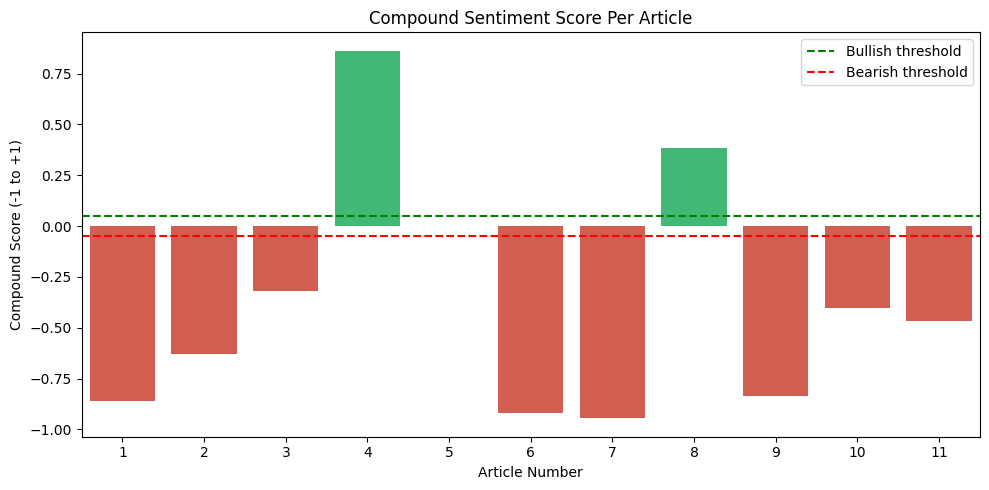

In [ ]:

# STEP 11: SENTIMENT SCORING


from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Score each article using cleaned full text
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores

df_clean["sentiment_scores"] = df_clean["full_text"].apply(get_sentiment)

# Extract individual scores
df_clean["pos"]      = df_clean["sentiment_scores"].apply(lambda x: x["pos"])
df_clean["neg"]      = df_clean["sentiment_scores"].apply(lambda x: x["neg"])
df_clean["neu"]      = df_clean["sentiment_scores"].apply(lambda x: x["neu"])
df_clean["compound"] = df_clean["sentiment_scores"].apply(lambda x: x["compound"])

# Show scores per article
print("=" * 50)
print("SENTIMENT SCORES PER ARTICLE")
print("=" * 50)
for i in range(len(df_clean)):
    print(f"\nArticle {i+1}: {df_clean['headline'].iloc[i]}")
    print(f"  Positive:  {df_clean['pos'].iloc[i]:.3f}")
    print(f"  Negative:  {df_clean['neg'].iloc[i]:.3f}")
    print(f"  Neutral:   {df_clean['neu'].iloc[i]:.3f}")
    print(f"  Compound:  {df_clean['compound'].iloc[i]:.3f}")

# Visualize compound scores per article
plt.figure(figsize=(10, 5))
colors = ["#2ecc71" if x >= 0.05 
          else "#e74c3c" if x <= -0.05 
          else "#f1c40f" 
          for x in df_clean["compound"]]
sns.barplot(
    x=list(range(1, len(df_clean)+1)),
    y=df_clean["compound"],
    palette=colors
)
plt.axhline(y=0.05,  color="green", linestyle="--", label="Bullish threshold")
plt.axhline(y=-0.05, color="red",   linestyle="--", label="Bearish threshold")
plt.title("Compound Sentiment Score Per Article")
plt.xlabel("Article Number")
plt.ylabel("Compound Score (-1 to +1)")
plt.legend()
plt.tight_layout()
plt.show()

FINAL SENTIMENT VERDICT
Asset:          OIL
Articles used:  11
Average Score:  -0.376
Final Score:    -38 / 100
Verdict:        BEARISH


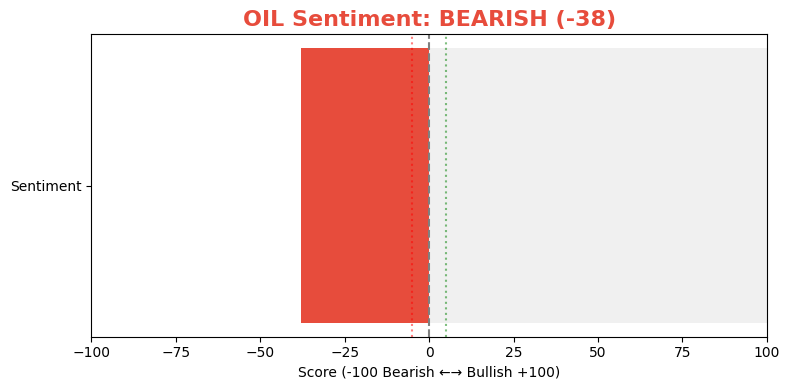

In [ ]:

# STEP 12: AGGREGATE SCORES → FINAL VERDICT

# Average compound score
avg_score = df_clean["compound"].mean()
final_score = round(avg_score * 100)

# Decide verdict
if avg_score >= 0.05:
    verdict = "BULLISH"
    color = "#2ecc71"
elif avg_score <= -0.05:
    verdict = "BEARISH"
    color = "#e74c3c"
else:
    verdict = "NEUTRAL"
    color = "#f1c40f"

print("=" * 50)
print("FINAL SENTIMENT VERDICT")
print("=" * 50)
print(f"Asset:          {asset_keyword.upper()}")
print(f"Articles used:  {len(df_clean)}")
print(f"Average Score:  {avg_score:.3f}")
print(f"Final Score:    {final_score} / 100")
print(f"Verdict:        {verdict}")

# Visualize final verdict - needle/gauge style
fig, ax = plt.subplots(figsize=(8, 4))

# Score bar
ax.barh(["Sentiment"], [final_score], 
        color=color, height=0.4)
ax.barh(["Sentiment"], [100], 
        color="#f0f0f0", height=0.4)
ax.axvline(x=0,   color="gray", linestyle="--")
ax.axvline(x=5,   color="green", linestyle=":", alpha=0.5)
ax.axvline(x=-5,  color="red",   linestyle=":", alpha=0.5)
ax.set_xlim(-100, 100)
ax.set_title(f"{asset_keyword.upper()} Sentiment: {verdict} ({final_score})", 
             fontsize=16, fontweight="bold", color=color)
ax.set_xlabel("Score (-100 Bearish ←→ Bullish +100)")
plt.tight_layout()
plt.show()

In [ ]:

# STEP 13: SAVE VERDICT TO DATABASE

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME"),
    use_pure=True
)
cursor = conn.cursor()

# Save to sentiment_results table
cursor.execute("""
    INSERT INTO sentiment_results 
    (asset, period, verdict, score, analyzed_at, expires_at)
    VALUES (%s, %s, %s, %s, NOW(), DATE_ADD(NOW(), INTERVAL 4 HOUR))
    ON DUPLICATE KEY UPDATE
        verdict = VALUES(verdict),
        score = VALUES(score),
        analyzed_at = NOW(),
        expires_at = DATE_ADD(NOW(), INTERVAL 4 HOUR)
""", (
    asset_keyword.upper(),
    "7d",
    verdict,
    final_score
))

conn.commit()
cursor.close()
conn.close()

print("=" * 50)
print("✅ VERDICT SAVED TO DATABASE!")
print("=" * 50)
print(f"Asset:   {asset_keyword.upper()}")
print(f"Period:  7d")
print(f"Verdict: {verdict}")
print(f"Score:   {final_score}")
print(f"Expires: 4 hours from now")

✅ VERDICT SAVED TO DATABASE!
Asset:   OIL
Period:  7d
Verdict: BEARISH
Score:   -38
Expires: 4 hours from now
